In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


TASK 1: Exploratory Probability Analysis

In [3]:
#1.1
p_churn = df['Churn'].value_counts(normalize=True)['Yes']
print(f"Overall churn probability: {p_churn:.2f}")

Overall churn probability: 0.27


In [4]:
# 1.2
p_churn_month = df[df['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize=True)['Yes']
p_churn_tenure = df[df['tenure'] < 12]['Churn'].value_counts(normalize=True)['Yes']
p_churn_fiber = df[df['InternetService'] == 'Fiber optic']['Churn'].value_counts(normalize=True)['Yes']
p_churn_echeck = df[df['PaymentMethod'] == 'Electronic check']['Churn'].value_counts(normalize=True)['Yes']

print(f"P(Churn | Month-to-month) = {p_churn_month:.2f}")
print(f"P(Churn | tenure<12) = {p_churn_tenure:.2f}")
print(f"P(Churn | Fiber optic) = {p_churn_fiber:.2f}")
print(f"P(Churn | Electronic check) = {p_churn_echeck:.2f}")


P(Churn | Month-to-month) = 0.43
P(Churn | tenure<12) = 0.48
P(Churn | Fiber optic) = 0.42
P(Churn | Electronic check) = 0.45


In [5]:
#1.3
joint_p = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic')
]['Churn'].eq('Yes').mean()

lift = joint_p / p_churn

print(f"Joint P(Churn | Month-to-month & Fiber optic) = {joint_p:.2f}")
print(f"Overall Churn probability = {p_churn:.2f}")
print(f"Lift = {lift:.2f}")

Joint P(Churn | Month-to-month & Fiber optic) = 0.55
Overall Churn probability = 0.27
Lift = 2.06


In [6]:
#1.4
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
print(contract_churn)
lowest_contract = contract_churn.idxmin()
print(f"Contract with lowest churn: {lowest_contract}")

senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x=='Yes').mean())
print(f"Non-seniors churn: {senior_churn[0]:.2f}")
print(f"Seniors churn: {senior_churn[1]:.2f}")

paperless_churn = df.groupby('PaperlessBilling')['Churn'].apply(lambda x: (x=='Yes').mean())
print(f"No paperless churn: {paperless_churn['No']:.2f}")
print(f"Paperless churn: {paperless_churn['Yes']:.2f}")
difference = paperless_churn['Yes'] - paperless_churn['No']
print(f"Difference: {difference:.2f}")

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
Contract with lowest churn: Two year
Non-seniors churn: 0.24
Seniors churn: 0.42
No paperless churn: 0.16
Paperless churn: 0.34
Difference: 0.17


Top 5 predictive features: ['Contract', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']


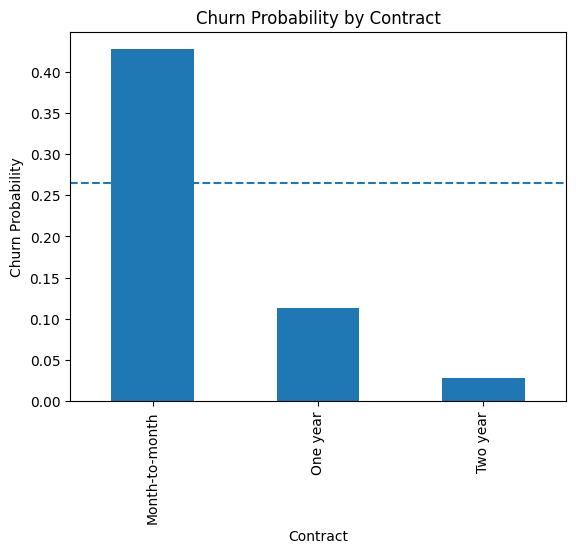

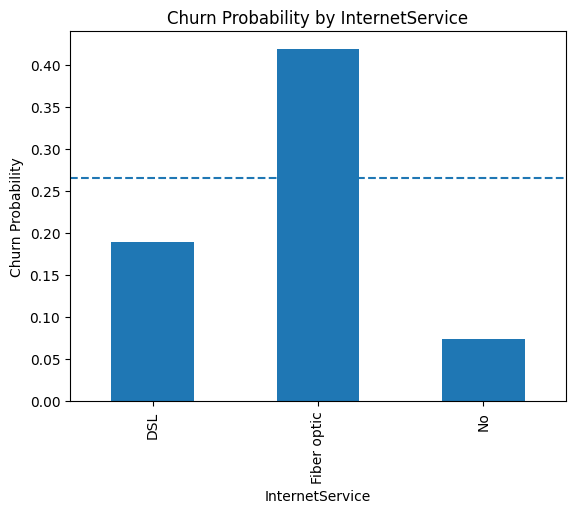

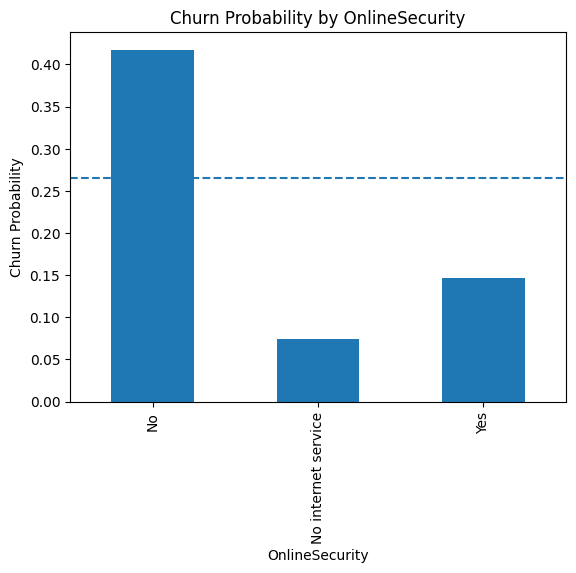

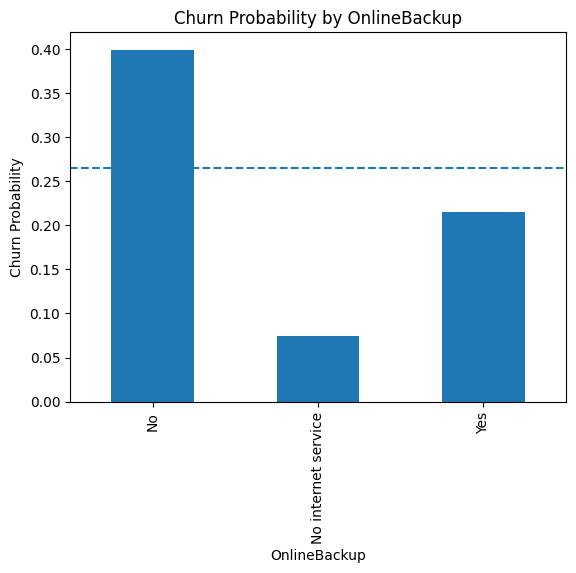

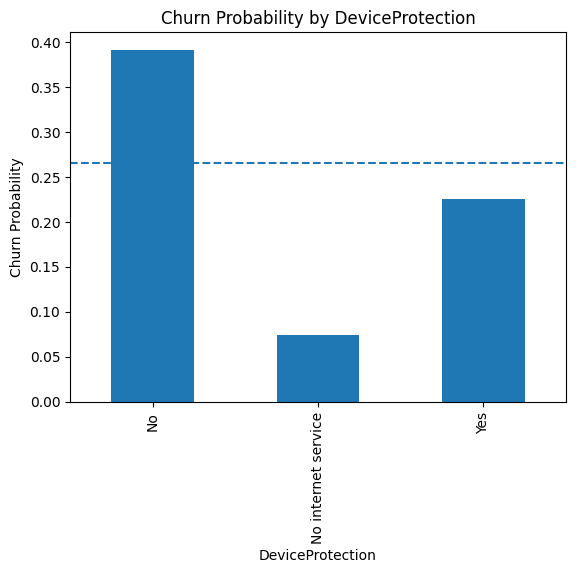

In [7]:
#1.5
categorical_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


feature_diff = {}

for col in categorical_features:
    probs = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    max_diff = (probs - p_churn).abs().max()
    feature_diff[col] = max_diff

top_features = sorted(feature_diff, key=feature_diff.get, reverse=True)[:5]

print("Top 5 predictive features:", top_features)


import matplotlib.pyplot as plt

for col in top_features:
    probs = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    
    plt.figure()
    probs.plot(kind='bar')
    plt.axhline(p_churn, linestyle='--')
    plt.title(f'Churn Probability by {col}')
    plt.ylabel('Churn Probability')
    plt.show()


TASK 2: Naive Bayes Classifier from Scratch 

In [8]:
#2.1
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']




y = df['Churn'].map({'Yes': 1, 'No': 0})

X = df[numerical_features + categorical_features]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



num_stats = {}

for col in numerical_features:
    num_stats[col] = {}
    
    for cls in [0, 1]:  
        data = X_train[y_train == cls][col]
        
        std = data.std()
        if std == 0:
            std = 1e-6  
        
        num_stats[col][cls] = {
            'mean': data.mean(),
            'variance': data.var(),
            'std': std
        }

import pprint
print("Statistics by classes:")
pprint.pprint(num_stats)


Statistics by classes:
{'MonthlyCharges': {0: {'mean': np.float64(61.452899951667476),
                        'std': np.float64(31.04248762970537),
                        'variance': np.float64(963.6360382404109)},
                    1: {'mean': np.float64(74.30020053475936),
                        'std': np.float64(24.968443762202064),
                        'variance': np.float64(623.4231839062471)}},
 'TotalCharges': {0: {'mean': np.float64(2553.57872160464),
                      'std': np.float64(2322.2272950738793),
                      'variance': np.float64(5392739.609986146)},
                  1: {'mean': np.float64(1559.3044786096257),
                      'std': np.float64(1902.6788101363304),
                      'variance': np.float64(3620186.6545418017)}},
 'tenure': {0: {'mean': np.float64(37.438134364427256),
                'std': np.float64(24.006287259604385),
                'variance': np.float64(576.3018279906438)},
            1: {'mean': np.float64(18.3

In [9]:
#2.2
prior_probs = {}
total_samples = len(y_train)
prior_probs[0] = sum(y_train == 0) / total_samples  
prior_probs[1] = sum(y_train == 1) / total_samples  
print("Prior probabilities:")
print(f"P(No Churn) = {prior_probs[0]:.2f}")
print(f"P(Churn) = {prior_probs[1]:.2f}")

cat_probs = {}
print("Conditional Probabilities (Categorical) ")
for col in categorical_features:
    cat_probs[col] = {}
    for cls in [0,1]:
        cat_probs[col][cls] = {}
        subset = X_train[y_train == cls]
        value_counts = subset[col].value_counts()
        total = len(subset)
        unique_values = X_train[col].nunique()  
        
        for val in value_counts.index:
            prob = (value_counts[val]+1) / (total + unique_values)
            cat_probs[col][cls][val] = prob
            print(f"P({col}={val} | Churn={cls}) = {prob:.3f}")
    print("\n")

    num_stats = {}

print(" Numerical Features Statistics (Gaussian) ")
for col in numerical_features:
    num_stats[col] = {}
    for cls in [0,1]:
        data = X_train[y_train == cls][col]
        std = data.std() if data.std() > 0 else 1e-6
        num_stats[col][cls] = {
            'mean': data.mean(),
            'std': std
        }
        print(f"{col} | Churn={cls} -> mean = {data.mean():.3f}, std = {std:.3f}")
    print("\n")



Prior probabilities:
P(No Churn) = 0.73
P(Churn) = 0.27
Conditional Probabilities (Categorical) 
P(gender=Male | Churn=0) = 0.516
P(gender=Female | Churn=0) = 0.484
P(gender=Male | Churn=1) = 0.503
P(gender=Female | Churn=1) = 0.497


P(SeniorCitizen=0 | Churn=0) = 0.871
P(SeniorCitizen=1 | Churn=0) = 0.129
P(SeniorCitizen=0 | Churn=1) = 0.749
P(SeniorCitizen=1 | Churn=1) = 0.251


P(Partner=Yes | Churn=0) = 0.527
P(Partner=No | Churn=0) = 0.473
P(Partner=No | Churn=1) = 0.634
P(Partner=Yes | Churn=1) = 0.366


P(Dependents=No | Churn=0) = 0.657
P(Dependents=Yes | Churn=0) = 0.343
P(Dependents=No | Churn=1) = 0.824
P(Dependents=Yes | Churn=1) = 0.176


P(PhoneService=Yes | Churn=0) = 0.900
P(PhoneService=No | Churn=0) = 0.100
P(PhoneService=Yes | Churn=1) = 0.906
P(PhoneService=No | Churn=1) = 0.094


P(MultipleLines=No | Churn=0) = 0.486
P(MultipleLines=Yes | Churn=0) = 0.415
P(MultipleLines=No phone service | Churn=0) = 0.100
P(MultipleLines=Yes | Churn=1) = 0.455
P(MultipleLines=No 

In [10]:
#2.3
import math

y_pred = []
y_prob = []

def gaussian_prob(x, mean, std):
    exponent = math.exp(-((x - mean) ** 2) / (2 * std**2))
    return (1 / (math.sqrt(2 * math.pi) * std)) * exponent

for i, row in X_test.iterrows():
    print(f"\n Customer index {i} ")
    probs = {}
    
    for cls in [0, 1]:  
        print(f"\nStep 1: Prior probability for class {cls}: P(class) = {prior_probs[cls]:.4f}")
        prob = prior_probs[cls]
        
    
        print("Step 2: Categorical features probabilities:")
        for col in categorical_features:
            val = row[col]
            p_val = cat_probs[col][cls].get(val, 1e-6)
            prob *= p_val
            print(f"  P({col}={val} | class={cls}) = {p_val:.6f}, cumulative prob = {prob:.6e}")
        
    
        print("Step 3: Numerical features probabilities (Gaussian):")
        for col in numerical_features:
            mean = num_stats[col][cls]['mean']
            std = num_stats[col][cls]['std']
            p_val = gaussian_prob(row[col], mean, std)
            prob *= p_val
            print(f"  P({col}={row[col]} | class={cls}) = {p_val:.6e}, cumulative prob = {prob:.6e}")
        
        probs[cls] = prob
    
    
    total = probs[0] + probs[1]
    probs[0] /= total
    probs[1] /= total
    print(f"\nStep 4: Normalized probabilities:")
    print(f"  P(NoChurn | features) = {probs[0]:.4f}")
    print(f"  P(Churn | features) = {probs[1]:.4f}")
    
    predicted_class = 1 if probs[1] > 0.5 else 0
    print(f"Step 5: Predicted class = {predicted_class}")
    
    y_pred.append(predicted_class)
    y_prob.append(probs[1])

y_pred = pd.Series(y_pred, index=X_test.index)
y_prob = pd.Series(y_prob, index=X_test.index)



 Customer index 185 

Step 1: Prior probability for class 0: P(class) = 0.7345
Step 2: Categorical features probabilities:
  P(gender=Female | class=0) = 0.484058, cumulative prob = 3.555257e-01
  P(SeniorCitizen=0 | class=0) = 0.871498, cumulative prob = 3.098398e-01
  P(Partner=Yes | class=0) = 0.527295, cumulative prob = 1.633769e-01
  P(Dependents=No | class=0) = 0.656522, cumulative prob = 1.072605e-01
  P(PhoneService=No | class=0) = 0.099758, cumulative prob = 1.070014e-02
  P(MultipleLines=No phone service | class=0) = 0.099734, cumulative prob = 1.067172e-03
  P(InternetService=DSL | class=0) = 0.378652, cumulative prob = 4.040872e-04
  P(OnlineSecurity=No | class=0) = 0.396523, cumulative prob = 1.602297e-04
  P(OnlineBackup=No | class=0) = 0.355711, cumulative prob = 5.699549e-05
  P(DeviceProtection=No | class=0) = 0.368269, cumulative prob = 2.098965e-05
  P(TechSupport=No | class=0) = 0.395557, cumulative prob = 8.302594e-06
  P(StreamingTV=No | class=0) = 0.359575, cumu


--- Evaluation Metrics for Custom Naive Bayes ---
Accuracy = 0.7331
Precision = 0.4976
Recall = 0.8365
F1-score = 0.6240

Confusion Matrix:
[[721 315]
 [ 61 312]]


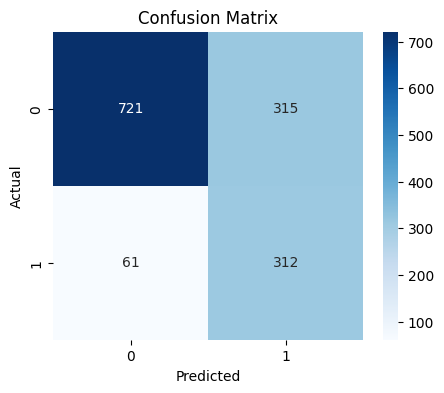


AUC = 0.8411


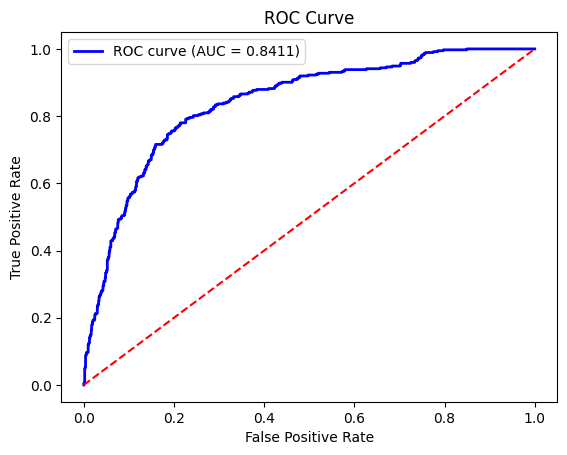

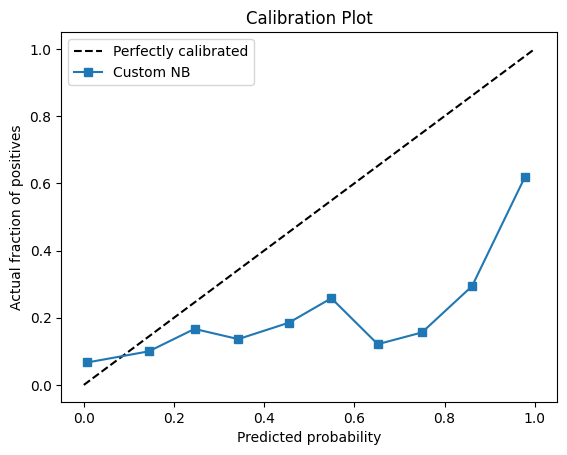

In [11]:
#2.4
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Evaluation Metrics for Custom Naive Bayes ---")
print(f"Accuracy = {acc:.4f}")
print(f"Precision = {prec:.4f}")
print(f"Recall = {rec:.4f}")
print(f"F1-score = {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC curve and AUC 
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"\nAUC = {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Calibration plot 
plt.figure()
bins = 10
bin_edges = np.linspace(0,1,bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
bin_probs = np.zeros(bins)
bin_actual = np.zeros(bins)

for i in range(bins):
    mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
    if mask.sum() > 0:
        bin_probs[i] = y_prob[mask].mean()
        bin_actual[i] = y_test[mask].mean()

plt.plot([0,1],[0,1], "k--", label="Perfectly calibrated")
plt.plot(bin_probs, bin_actual, "s-", label="Custom NB")
plt.xlabel("Predicted probability")
plt.ylabel("Actual fraction of positives")
plt.title("Calibration Plot")
plt.legend()
plt.show()


In [12]:
#2.5
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


X_train_enc = X_train.copy()
X_test_enc = X_test.copy()


for col in categorical_features:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])


sk_nb = GaussianNB()
sk_nb.fit(X_train_enc, y_train)

y_pred_skl = sk_nb.predict(X_test_enc)
y_prob_skl = sk_nb.predict_proba(X_test_enc)[:, 1]


metrics_skl = {
    "Accuracy": accuracy_score(y_test, y_pred_skl),
    "Precision": precision_score(y_test, y_pred_skl),
    "Recall": recall_score(y_test, y_pred_skl),
    "F1-score": f1_score(y_test, y_pred_skl)
}

metrics_custom = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}


print("\n Comparison: Custom NB vs Sklearn NB ")
for metric in metrics_custom:
    print(f"{metric}: Custom NB = {metrics_custom[metric]:.4f}, Sklearn NB = {metrics_skl[metric]:.4f}")


print("\nComments:")
print("- Usually, the results of Custom NB and Sklearn NB are similar if categorical features are encoded and smoothing is applied.")
print("- Differences may arise due to the handling of categorical features or numerical rounding errors.")
print("- Sklearn NB is often more stable on small datasets and when numerical features do not follow a normal distribution.")



 Comparison: Custom NB vs Sklearn NB 
Accuracy: Custom NB = 0.7331, Sklearn NB = 0.7566
Precision: Custom NB = 0.4976, Sklearn NB = 0.5275
Recall: Custom NB = 0.8365, Sklearn NB = 0.7721
F1-score: Custom NB = 0.6240, Sklearn NB = 0.6268

Comments:
- Usually, the results of Custom NB and Sklearn NB are similar if categorical features are encoded and smoothing is applied.
- Differences may arise due to the handling of categorical features or numerical rounding errors.
- Sklearn NB is often more stable on small datasets and when numerical features do not follow a normal distribution.


In [13]:
#3.1
CLV = 2000
COST = 300
SUCCESS = 0.4
df = df.reset_index(drop=True)
y_prob = y_prob.reset_index(drop=True)

df['Churn_Probability'] = y_prob


churn_prob = 0.8
max_spend = churn_prob * SUCCESS * CLV
print(f"Maximum retention spend for customer with P(Churn)=0.8: ${max_spend:.2f}")

df['Expected_Value'] = (
    df['Churn_Probability'] * CLV * SUCCESS
    - COST
)


target = df[df['Churn_Probability'] > 0.5].copy()

total_profit = target['Expected_Value'].sum()

print("Number of targeted customers:", len(target))
print("Total expected profit:", total_profit)


Maximum retention spend for customer with P(Churn)=0.8: $640.00
Number of targeted customers: 627
Total expected profit: 267777.4973174465


=== Risk Segmentation Matrix ===
  Value_Segment Risk_Segment  Number_of_Customers  Total_Expected_Loss  \
0    High Value    High Risk                  302        563149.334441   
1    High Value     Low Risk                 3281         55630.267498   
2     Low Value    High Risk                  294        542508.699698   
3     Low Value     Low Risk                 3166         51893.844275   

   Total_Net_Gain  Total_Cost       ROI  
0   134659.733776       90600  1.486311  
1  -110347.893001      984300 -0.112108  
2   128803.479879       88200  1.460357  
3   -90542.462290      949800 -0.095328  

Quadrant with highest ROI:
Value_Segment             High Value
Risk_Segment               High Risk
Number_of_Customers              302
Total_Expected_Loss    563149.334441
Total_Net_Gain         134659.733776
Total_Cost                     90600
ROI                         1.486311
Name: 0, dtype: object


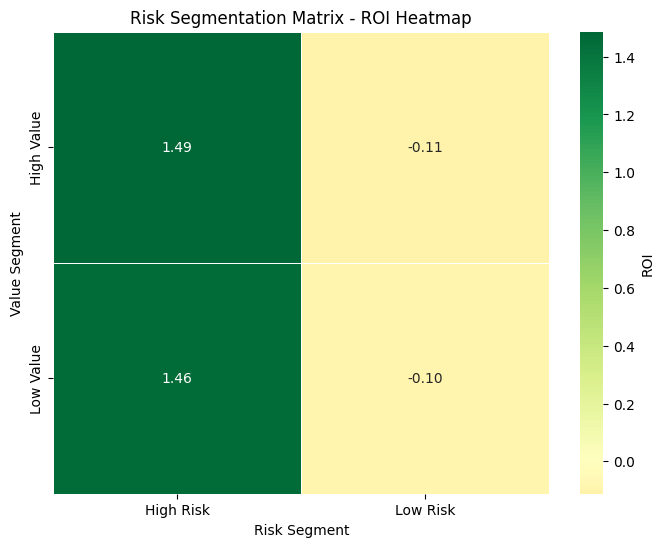

In [14]:
#3.2
CLV = 2000
COST = 300
SUCCESS = 0.4

df['Value_Segment'] = np.where(df['MonthlyCharges'] > 70, 'High Value', 'Low Value')
df['Risk_Segment'] = np.where(df['Churn_Probability'] > 0.6, 'High Risk', 'Low Risk')

#Expected churn loss и net gain 
df['Expected_Loss'] = df['Churn_Probability'] * CLV
df['Net_Gain'] = df['Churn_Probability'] * CLV * SUCCESS - COST

matrix = df.groupby(['Value_Segment', 'Risk_Segment']).agg(
    Number_of_Customers=('MonthlyCharges', 'count'),
    Total_Expected_Loss=('Expected_Loss', 'sum'),
    Total_Net_Gain=('Net_Gain', 'sum')
).reset_index()

# 4. ROI
matrix['Total_Cost'] = matrix['Number_of_Customers'] * COST
matrix['ROI'] = matrix['Total_Net_Gain'] / matrix['Total_Cost']

print("=== Risk Segmentation Matrix ===")
print(matrix)

best_quadrant = matrix.loc[matrix['ROI'].idxmax()]
print("\nQuadrant with highest ROI:")
print(best_quadrant)
pivot_roi = matrix.pivot(index='Value_Segment', columns='Risk_Segment', values='ROI')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_roi, annot=True, fmt=".2f", cmap='RdYlGn', center=0, linewidths=.5, cbar_kws={'label': 'ROI'})
plt.title("Risk Segmentation Matrix - ROI Heatmap")
plt.ylabel("Value Segment")
plt.xlabel("Risk Segment")
plt.show()


In [ ]:
#3.3

budget = 50000
retention_cost = 300

df['Expected_Value'] = df['Churn_Probability'] * 2000 * 0.4 - 300


df_sorted = df.sort_values(by='Expected_Value', ascending=False)

max_customers = math.floor(budget / retention_cost)

targeted = df_sorted.head(max_customers)

number_targeted = len(targeted)
total_expected_profit = targeted['Expected_Value'].sum()

high_risk_total = df[df['Churn_Probability'] > 0.6].shape[0]
high_risk_covered = targeted[targeted['Churn_Probability'] > 0.6].shape[0]

high_risk_coverage = (high_risk_covered / high_risk_total) * 100 if high_risk_total > 0 else 0

print("\n Budget Optimization ")
print("Number of customers targeted:", number_targeted)
print("Total expected profit:", total_expected_profit)
print("High-risk coverage (%):", high_risk_coverage)



=== Budget Optimization ===
Number of customers targeted: 166
Total expected profit: 82639.24359941838
High-risk coverage (%): 27.85234899328859


In [16]:
#3.4
def run_scenario(success_rate, retention_cost, avg_clv):
    df_copy = df.copy()
    
    df_copy['EV'] = df_copy['Churn_Probability'] * avg_clv * success_rate - retention_cost
    
    df_sorted = df_copy.sort_values(by='EV', ascending=False)
    
    budget = 50000
    max_customers = budget // retention_cost
    
    targeted = df_sorted.head(max_customers)
    
    total_profit = targeted['EV'].sum()
    
    return total_profit, len(targeted)

# Scenario 1
print("20% success:", run_scenario(0.2, 300, 2000))

# Scenario 2
print("Cost 500:", run_scenario(0.4, 500, 2000))

# Scenario 3
print("CLV 1500:", run_scenario(0.4, 300, 1500))


20% success: (np.float64(16419.621799709195), 166)
Cost 500: (np.float64(29876.515789073474), 100)
CLV 1500: (np.float64(49529.43269956379), 166)
